<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# Machine Learning Foundation

## Course 5, Part a: Gradient Descent DEMO


## Overview
In this notebook, we will solve a simple linear regression problem by gradient descent.  
We will see the effect of the learning rate on the trajectory in parameter space.
We will show how Stochastic Gradient Descent (SGD) differs from the standard version, and the effect of "shuffling" your data during SGD.


In [2]:
# Preliminaries - packages to load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Generate Data from a known distribution
Below we will generate data a known distribution.  
Specifically, the true model is:

$Y = b + \theta_1 X_1 + \theta_2 X_2 + \epsilon$

$X_1$ and $X_2$ have a uniform distribution on the interval $[0,10]$, while `const` is a vector of ones (representing the intercept term).

We set actual values for $b$ ,$\theta_1$, and $\theta_2$

Here $b=1.5$, $\theta_1=2$, and $\theta_2=5$

We then generate a vector of $y$-values according to the model and put the predictors together in a "feature matrix" `x_mat`


In [3]:
np.random.seed(1234)  ## This ensures we get the same data if all of the other parameters remain fixed

num_obs = 100
x1 = np.random.uniform(0,10,num_obs)
x2 = np.random.uniform(0,10,num_obs)
const = np.ones(num_obs)
eps = np.random.normal(0,.5,num_obs)

b = 1.5
theta_1 = 2
theta_2 = 5

y = b*const+ theta_1*x1 + theta_2*x2 + eps

x_mat = np.array([const,x1,x2]).T

In [11]:
x_mat

array([[1.        , 1.9151945 , 7.67116628],
       [1.        , 6.22108771, 7.08115362],
       [1.        , 4.37727739, 7.96867184],
       [1.        , 7.85358584, 5.57760828],
       [1.        , 7.79975808, 9.65836532],
       [1.        , 2.72592605, 1.471569  ],
       [1.        , 2.76464255, 0.29647001],
       [1.        , 8.01872178, 5.93893493],
       [1.        , 9.58139354, 1.14065699],
       [1.        , 8.75932635, 9.5080985 ],
       [1.        , 3.5781727 , 3.25707414],
       [1.        , 5.00995126, 1.9361869 ],
       [1.        , 6.83462935, 4.57811649],
       [1.        , 7.12702027, 9.20402571],
       [1.        , 3.70250755, 8.79069162],
       [1.        , 5.61196186, 2.52615755],
       [1.        , 5.03083165, 3.48008793],
       [1.        , 0.1376845 , 1.82588732],
       [1.        , 7.72826622, 9.01796051],
       [1.        , 8.82641191, 7.06528163],
       [1.        , 3.64885984, 7.26658462],
       [1.        , 6.15396178, 9.00087837],
       [1.

## Get the "Right" answer directly
In the below cells we solve for the optimal set of coefficients.  Note that even though the true model is given by:

$b=1.5$, $\theta_1=2$, and $\theta_2=5$

The maximum likelihood (least-squares) estimate from a finite data set may be slightly different.


## Exercise:
Solve the problem two ways: 
1. By using the scikit-learn LinearRegression model
2. Using matrix algebra directly via the formula $\theta = (X^T X)^{-1}X^Ty$
因为已知$X^T X \theta=X^Ty$ ，$ X \theta=y$

Note: The scikit-learn solver may give a warning message, this can be ignored.


In [4]:
### Solve directly using sklearn
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression(fit_intercept=False)
lr_model.fit(x_mat, y)

lr_model.coef_

array([1.49004618, 1.99675416, 5.01156315])

In [5]:
## Solve by matrix calculation
np.linalg.inv(np.dot(x_mat.T,x_mat)).dot(x_mat.T).dot(y)

array([1.49004618, 1.99675416, 5.01156315])

## Solving by Gradient Descent


For most numerical problems, we don't / can't know the underlying analytical solution. This is because we only arrive at analytical solutions by solving the equations mathematically, with pen and paper. That is more often than not just impossible. Fortunately, we have a way of converging to an approximate solution, by using **Gradient Descent**.


We will explore this very useful method because Neural Networks, along with many other complicated algorithms, are trained using Gradient Descent.  Seeing how gradient descent works on a simple example will build intuition and help us understand some of the nuances around setting the learning rate and other parameters.  We will also explore Stochastic Gradient Descent and compare its behavior to the standard approach.


## Exercise

The next several cells have code to perform (full-batch) gradient descent.  We have omitted some parameters for you to fill in.

1. Pick a learning rate, and a number of iterations, run the code, and then plot the trajectory of your gradient descent.
1. Find examples where the learning rate is too high, too low, and "just right".
1. Look at plots of loss function under these conditions.



In [6]:
## Parameters to play with 
learning_rate = 1e-3
num_iter = 10000
theta_initial = np.array([3,3,3])

In [7]:
def gradient_descent(learning_rate, num_iter, theta_initial):

    ## Initialization steps
    theta = theta_initial
    theta_path = np.zeros((num_iter+1,3))
    theta_path[0,:]= theta_initial

    loss_vec = np.zeros(num_iter)

    ## Main Gradient Descent loop (for a fixed number of iterations)
    for i in range(num_iter):
        y_pred = np.dot(theta.T,x_mat.T)
        loss_vec[i] = np.sum((y-y_pred)**2)
        grad_vec = (y-y_pred).dot(x_mat)/num_obs  #sum up the gradients across all observations and divide by num_obs
        grad_vec = grad_vec
        theta = theta + learning_rate*grad_vec
        theta_path[i+1,:]=theta
    return theta_path, loss_vec

下面这段代码实现了一个“批量梯度下降”（Batch Gradient Descent）过程，用于最小化平方损失并寻找线性模型的最佳参数。逐步解释如下：

```python
def gradient_descent(learning_rate, num_iter, theta_initial):
```
- 定义函数 `gradient_descent`，参数分别是：
  - `learning_rate`：学习率 \(\eta\)，控制每次更新步长；
  - `num_iter`：迭代次数 \(T\)；
  - `theta_initial`：初始参数向量 \(\boldsymbol\theta^{(0)}\)。

```python
    ## Initialization steps
    theta = theta_initial
    theta_path = np.zeros((num_iter+1, 3))
    theta_path[0, :] = theta_initial

    loss_vec = np.zeros(num_iter)
```
- **初始化**  
  1. `theta`：当前参数向量，初始时设为 `theta_initial`。  
  2. `theta_path`：用于记录每次迭代后的参数值轨迹，形状为 \((T+1)\times 3\)。这里假设模型有 3 个参数，因此第二维是 3。  
     - `theta_path[0, :]` 存储初始参数。  
  3. `loss_vec`：长度为 \(T\) 的数组，用来存放每次迭代计算出的平方损失值。

```python
    ## Main Gradient Descent loop (for a fixed number of iterations)
    for i in range(num_iter):
        y_pred = np.dot(theta.T, x_mat.T)
        loss_vec[i] = np.sum((y - y_pred)**2)
```
- **主循环**：对 \(i=0,1,\dots,T-1\)  
  1. `y_pred`：用当前参数 `theta` 对所有样本做预测。  
     - 假设 `x_mat` 是形状 \((N,3)\) 的设计矩阵，`theta` 是 \((3,)\) 向量，则 `theta.T @ x_mat.T` 得到长度为 \(N\) 的预测值。  
  2. `loss_vec[i]`：计算当前的**总平方损失**  
     \[
       L^{(i)} = \sum_{j=1}^N \bigl(y_j - \hat y_j\bigr)^2
     \]
     并存入损失记录数组。

```python
        grad_vec = (y - y_pred).dot(x_mat) / num_obs
```
- **计算梯度向量**  
  \[
    \nabla_{\theta}L
    = \frac{1}{N}\sum_{j=1}^N (y_j - \hat y_j)\,\mathbf{x}_j
  \]
  这里用 `(y - y_pred).dot(x_mat)/num_obs`，对所有样本的残差乘以对应特征后累加并平均，得到和损失函数（未乘 2）相符的梯度向量。

```python
        theta = theta + learning_rate * grad_vec
        theta_path[i+1, :] = theta
```
- **参数更新**  
  - 梯度上升的形式：\(\theta \leftarrow \theta + \eta\,\nabla_{\theta}L\)。（如果梯度定义中已经带有负号，则此处是“沿负梯度方向”下降。）  
  - 将更新后的参数存入 `theta_path` 的第 \(i+1\) 行，记录整个迭代过程。

```python
    return theta_path, loss_vec
```
- **返回值**  
  - `theta_path`：\((T+1)\times 3\) 的矩阵，包含从初始值到每次迭代后参数的完整轨迹；  
  - `loss_vec`：长度为 \(T\) 的向量，每个元素是对应迭代下的总平方损失。

---

**整体流程**：  
1. 用初始参数开始；  
2. 重复 \(T\) 步：  
   - 根据现有参数预测、计算损失；  
   - 计算损失关于参数的梯度；  
   - 按学习率更新参数；  
   - 记录参数轨迹和损失；  
3. 最终返回整个轨迹和损失序列，便于后续可视化收敛过程或选择最优迭代次数。

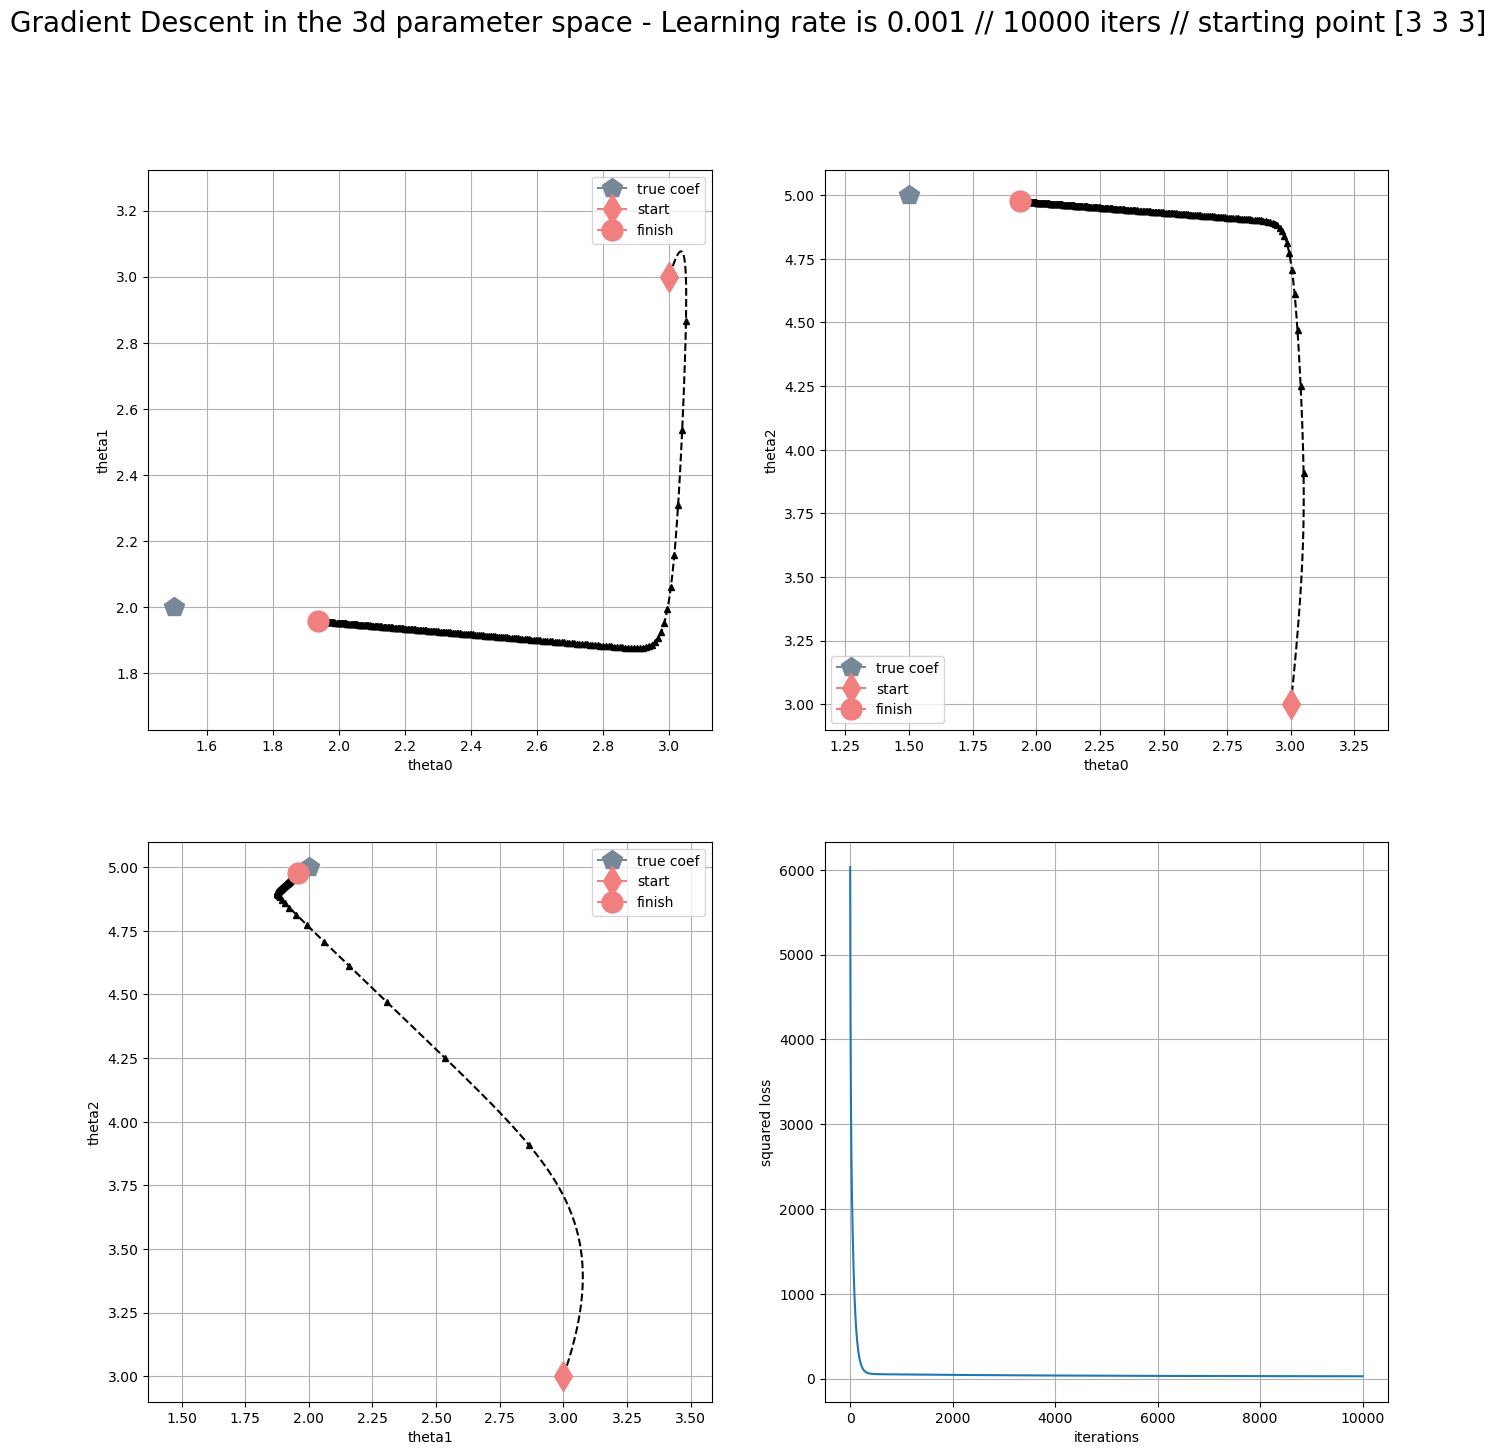

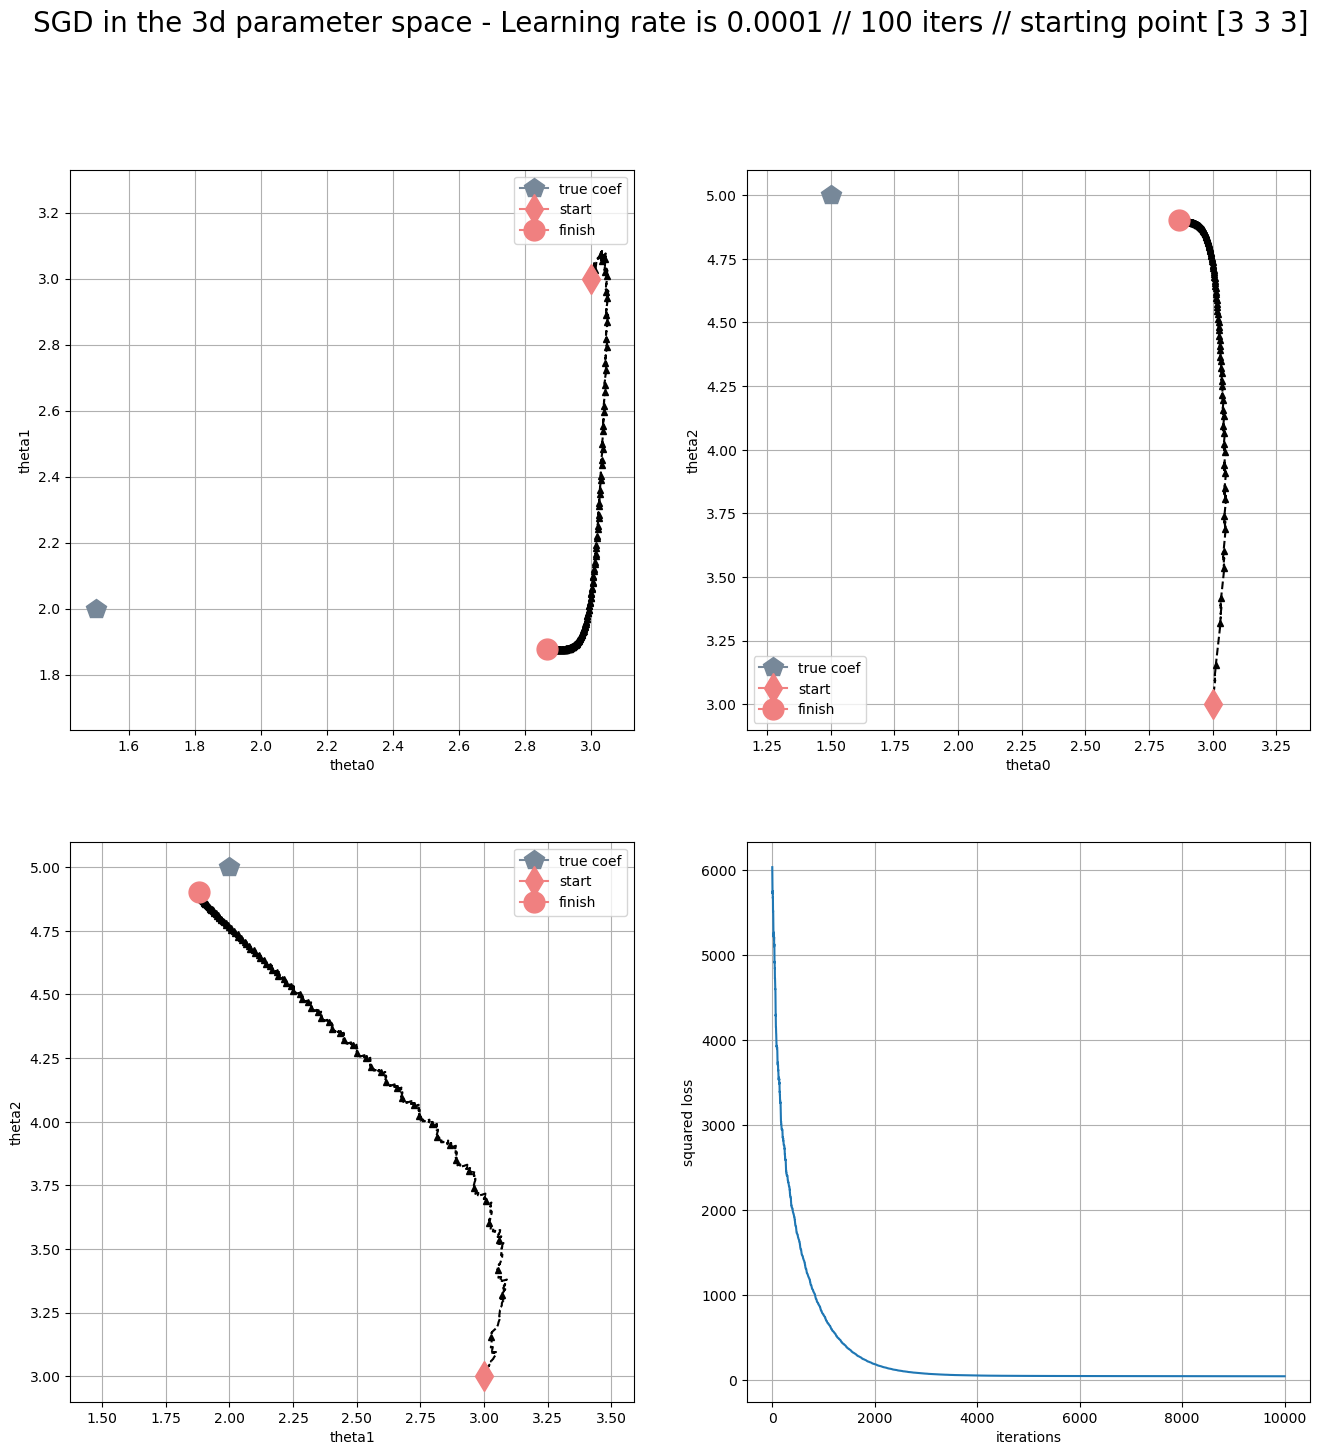

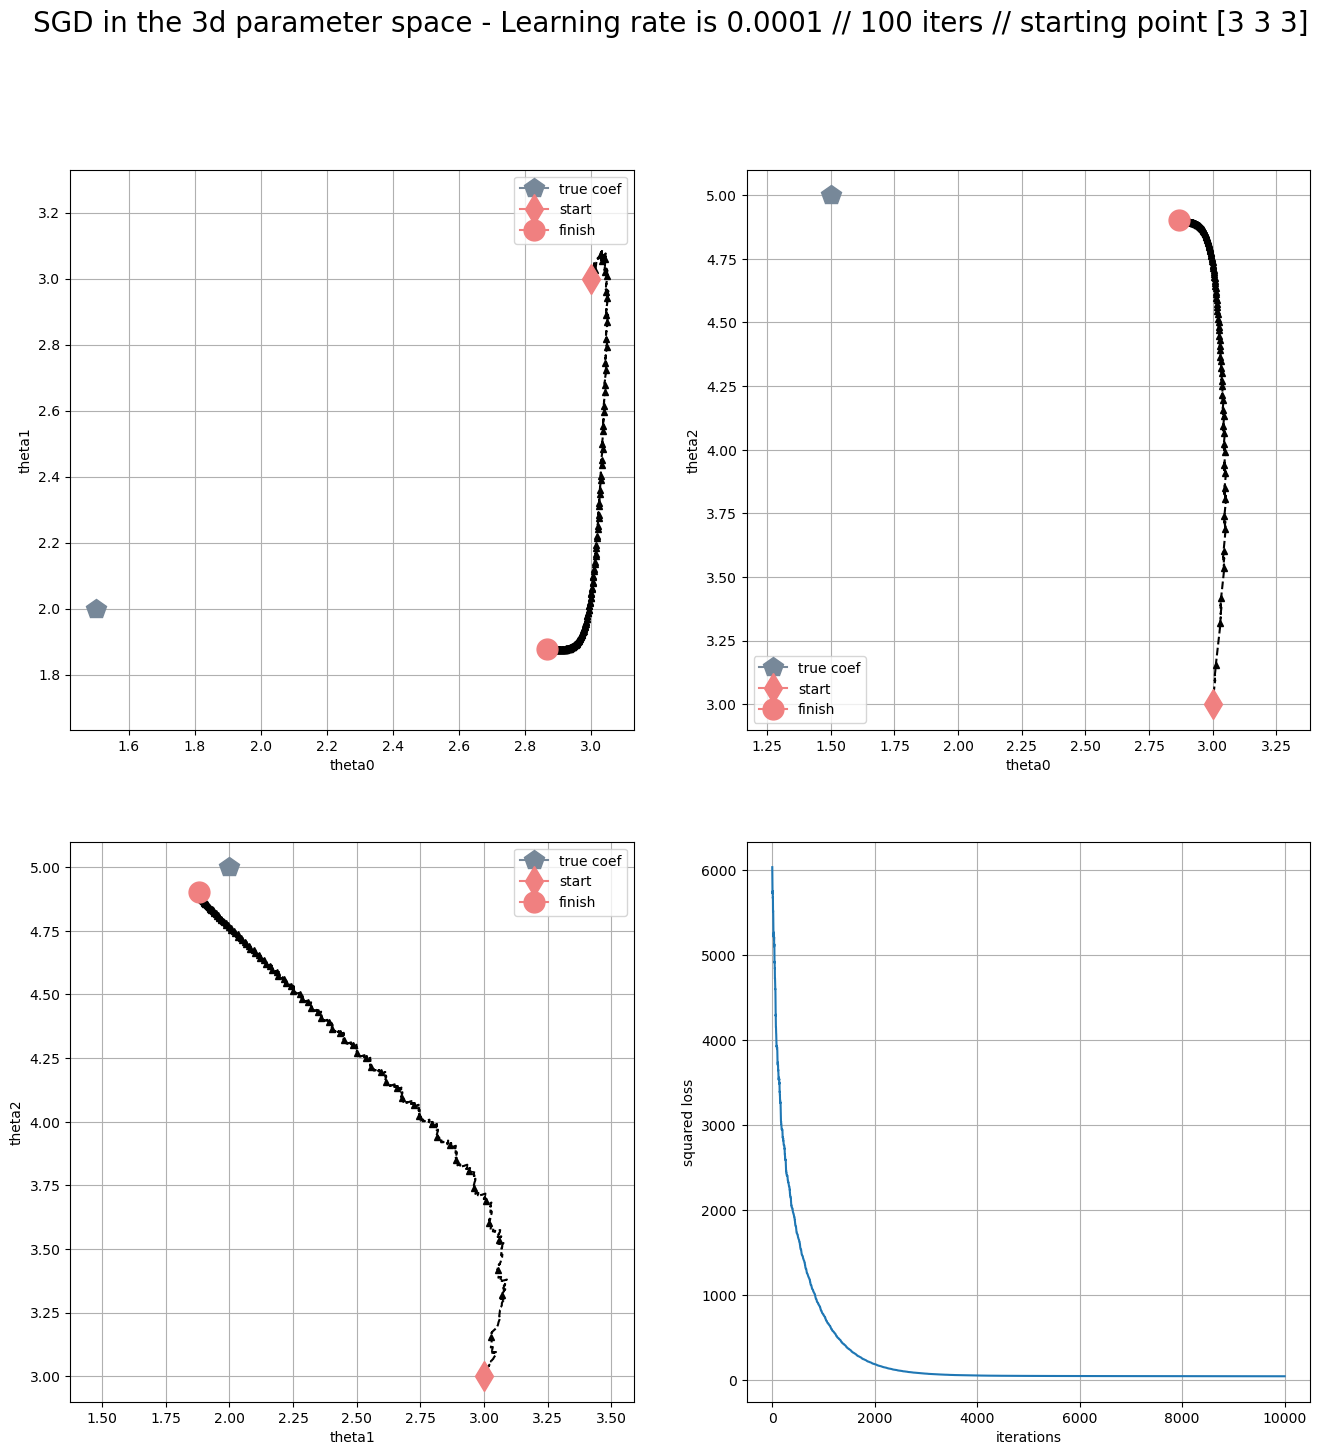

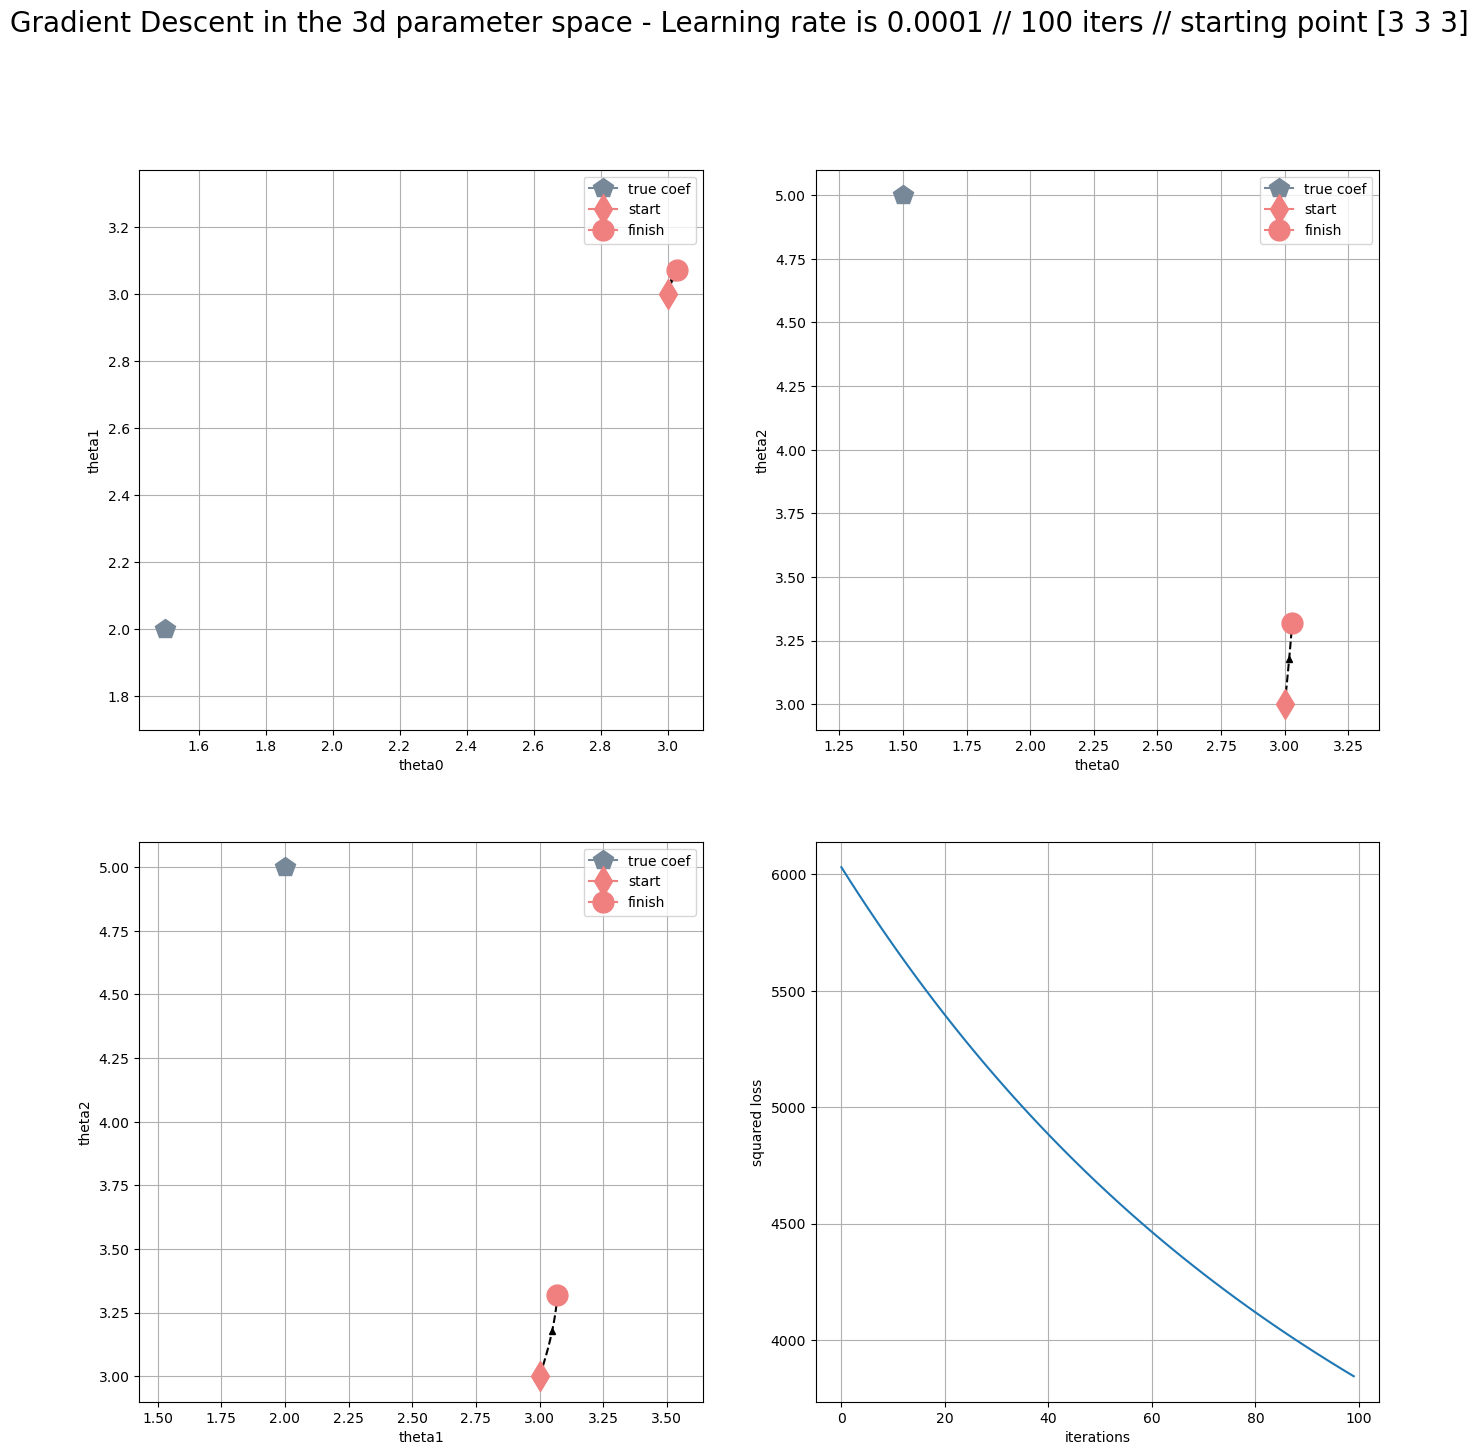

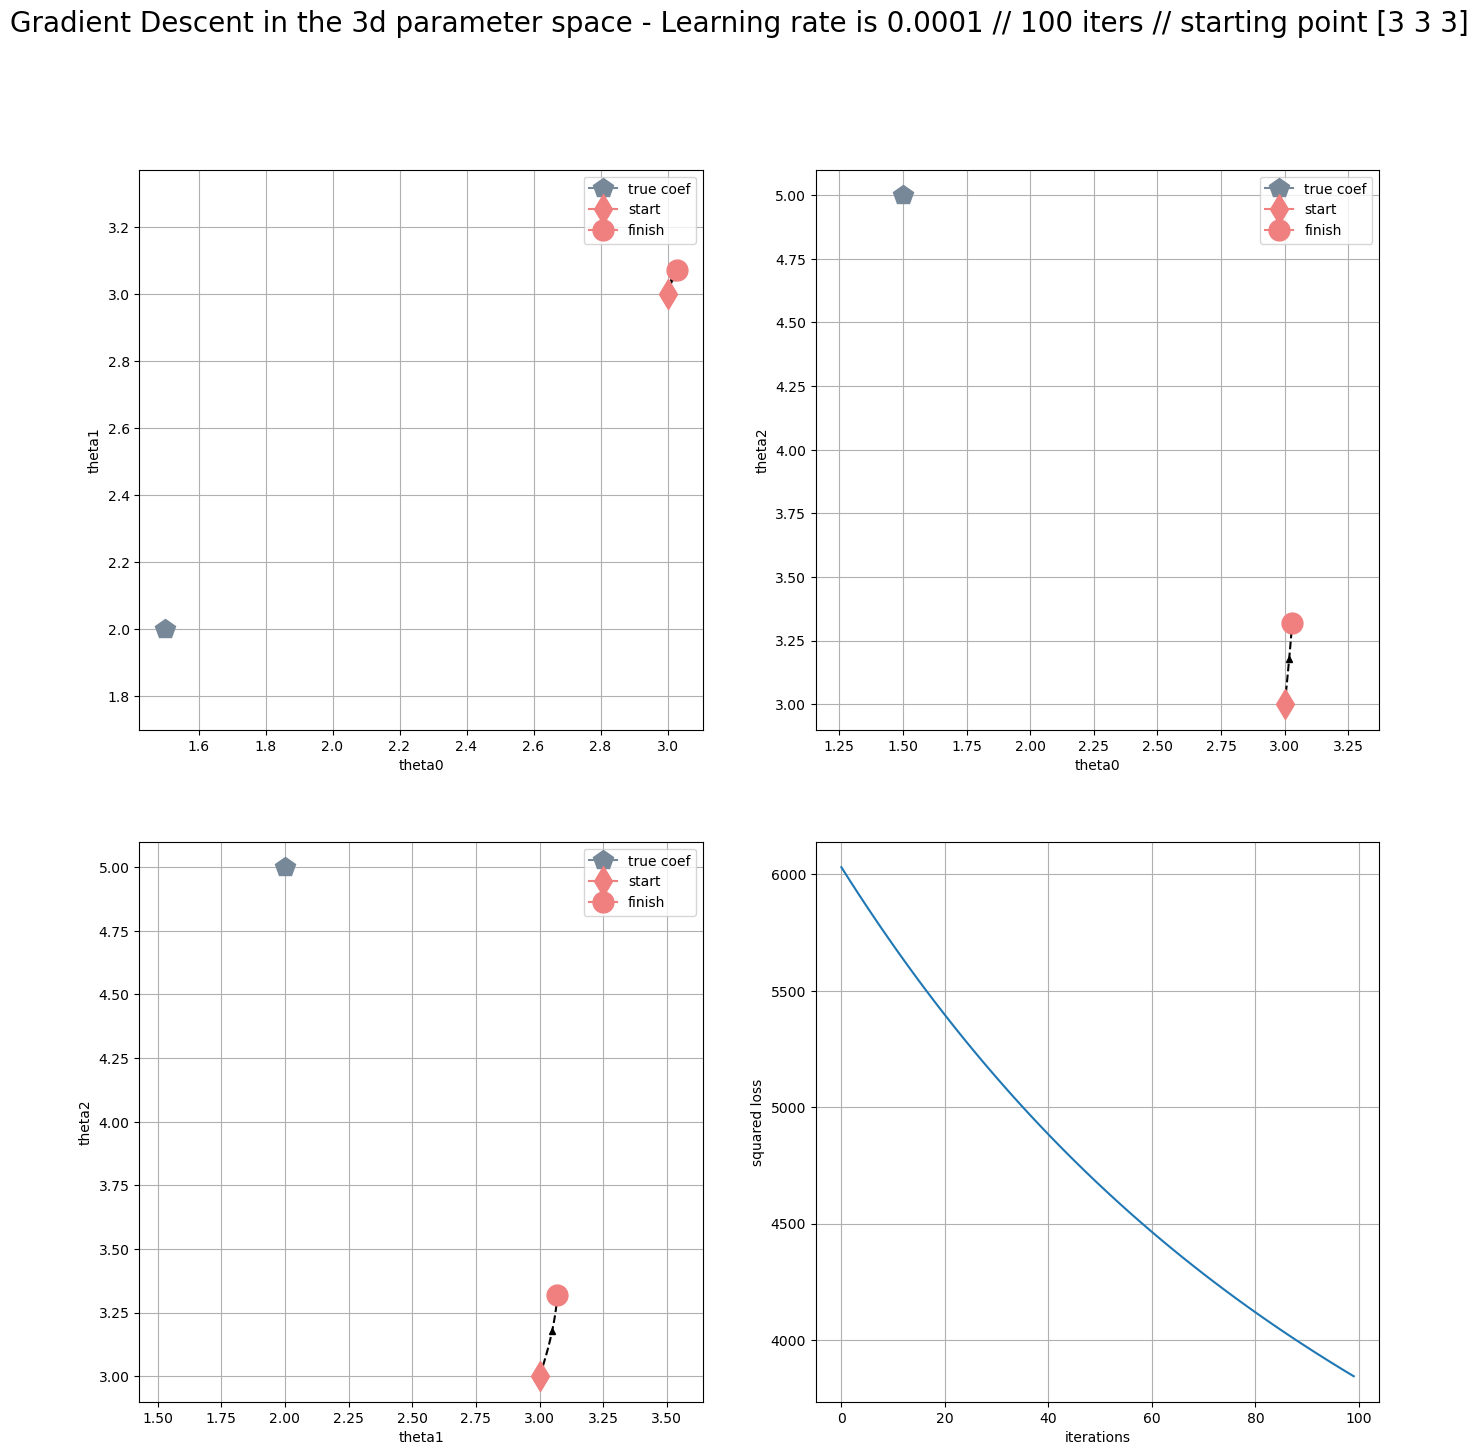

In [13]:
true_coef = [b, theta_1, theta_2]

def plot_ij(theta_path, i, j, ax):
    ax.plot(true_coef[i], true_coef[j],
            marker='p', markersize=15, label='true coef', 
            color='#778899')
    ax.plot(theta_path[:, i],theta_path[:, j],
            color='k', linestyle='--', marker='^', 
            markersize=5, markevery=50)
    ax.plot(theta_path[0, i], theta_path[0, j], marker='d', 
            markersize=15, label='start', color='#F08080')
    ax.plot(theta_path[-1, i], theta_path[-1, j], marker='o', 
            markersize=15, label='finish', color='#F08080')
    ax.set(
        xlabel='theta'+str(i),
        ylabel='theta'+str(j))
    ax.axis('equal')
    ax.grid(True)
    ax.legend(loc='best')
    

def plot_all(theta_path, loss_vec, learning_rate, num_iter, theta_initial, gdtype='Gradient Descent'):
    fig = plt.figure(figsize=(16, 16))
    title = '{gdtype} in the 3d parameter space - Learning rate is {lr} // {iters} iters // starting point {initial}'
    title = title.format(gdtype=gdtype, lr=learning_rate, 
                         iters=num_iter, initial=theta_initial)
    fig.suptitle(title, fontsize=20)
    ax = fig.add_subplot(2, 2, 1)
    plot_ij(theta_path, 0, 1, ax)
    ax = fig.add_subplot(2, 2, 2)
    plot_ij(theta_path, 0, 2, ax)
    ax = fig.add_subplot(2, 2, 3)
    plot_ij(theta_path, 1, 2, ax)
    ax = fig.add_subplot(2, 2, 4)
    ax.plot(loss_vec)
    ax.set(xlabel='iterations', ylabel='squared loss')
    ax.grid(True)
    

theta_path, loss_vec = gradient_descent(learning_rate, num_iter, theta_initial)
plot_all(theta_path, loss_vec, learning_rate, num_iter, theta_initial)
plt.show()



## Stochastic Gradient Descent
Rather than average the gradients across the whole dataset before taking a step, we will now take a step for every datapoint.  Each step will be somewhat of an "overreaction" but they should average out.  


## Exercise
The below code runs Stochastic Gradient descent, but runs through the data in the same order every time.  

1. Run the code and plot the graphs.  What do you notice?
2. Modify the code so that it randomly re-orders the data.  How do the sample trajectories compare?


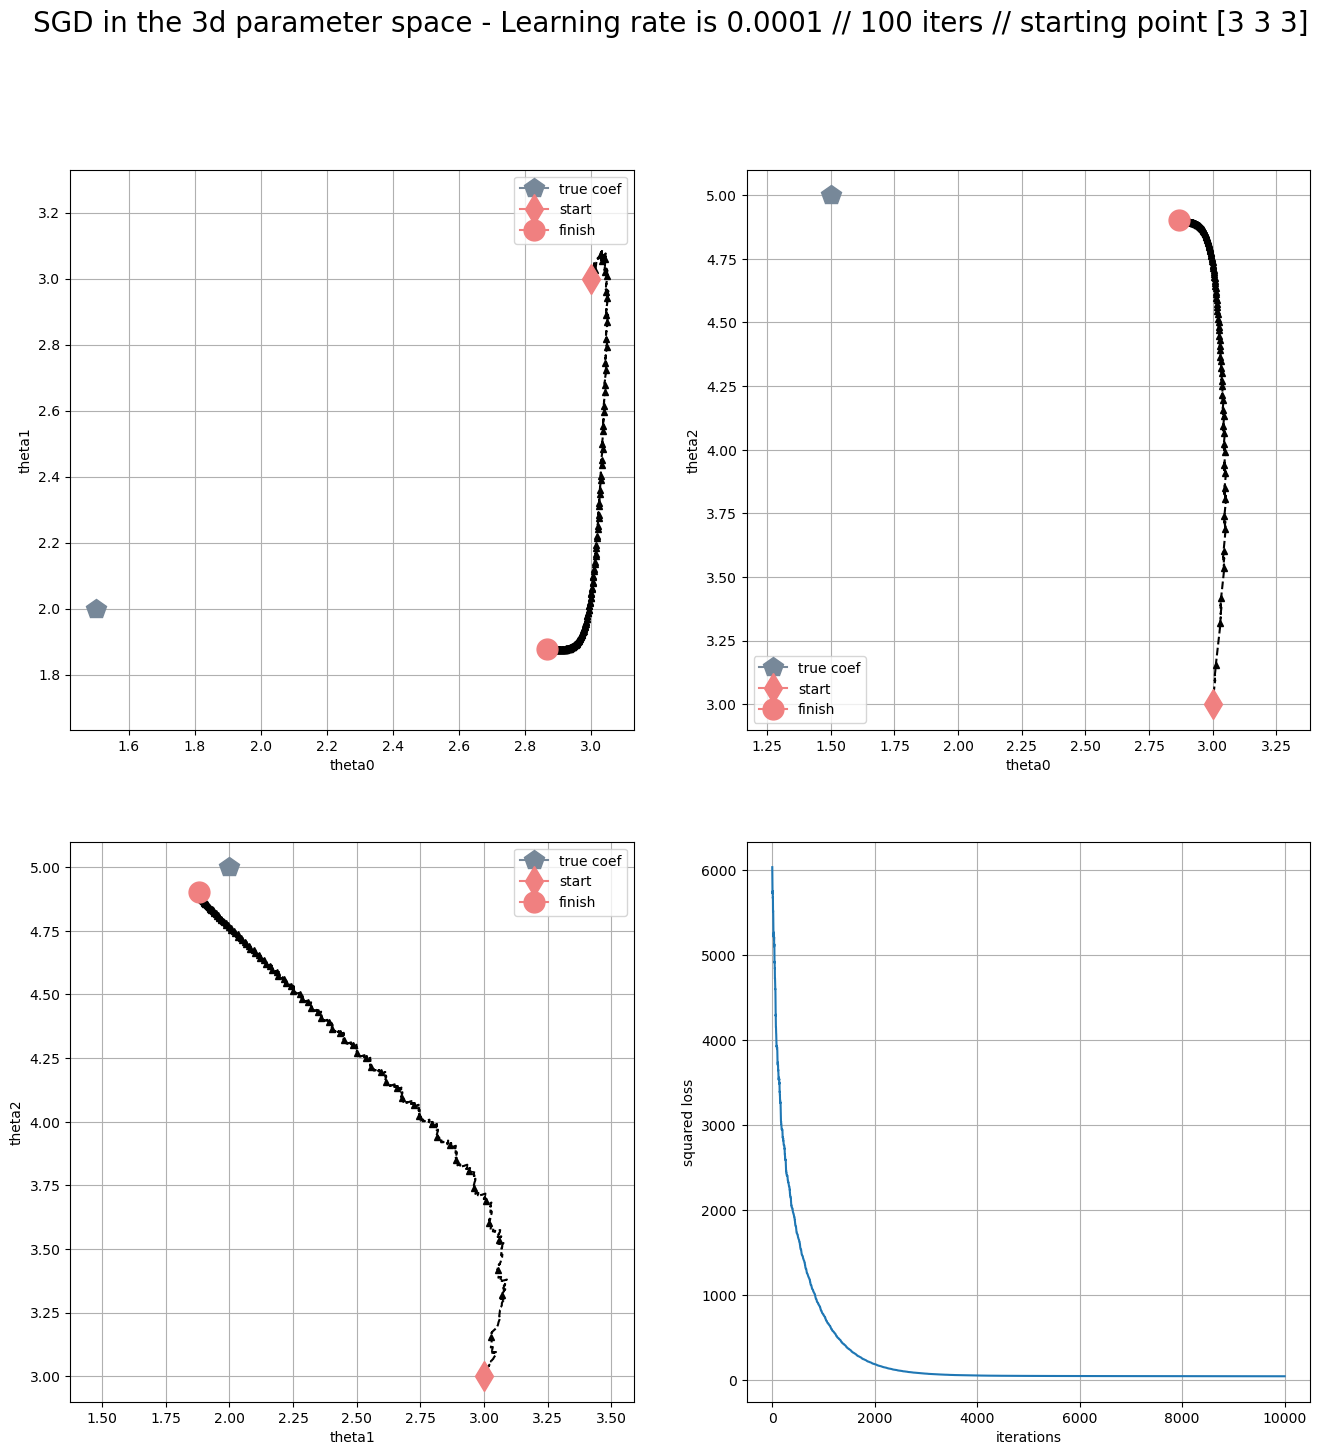

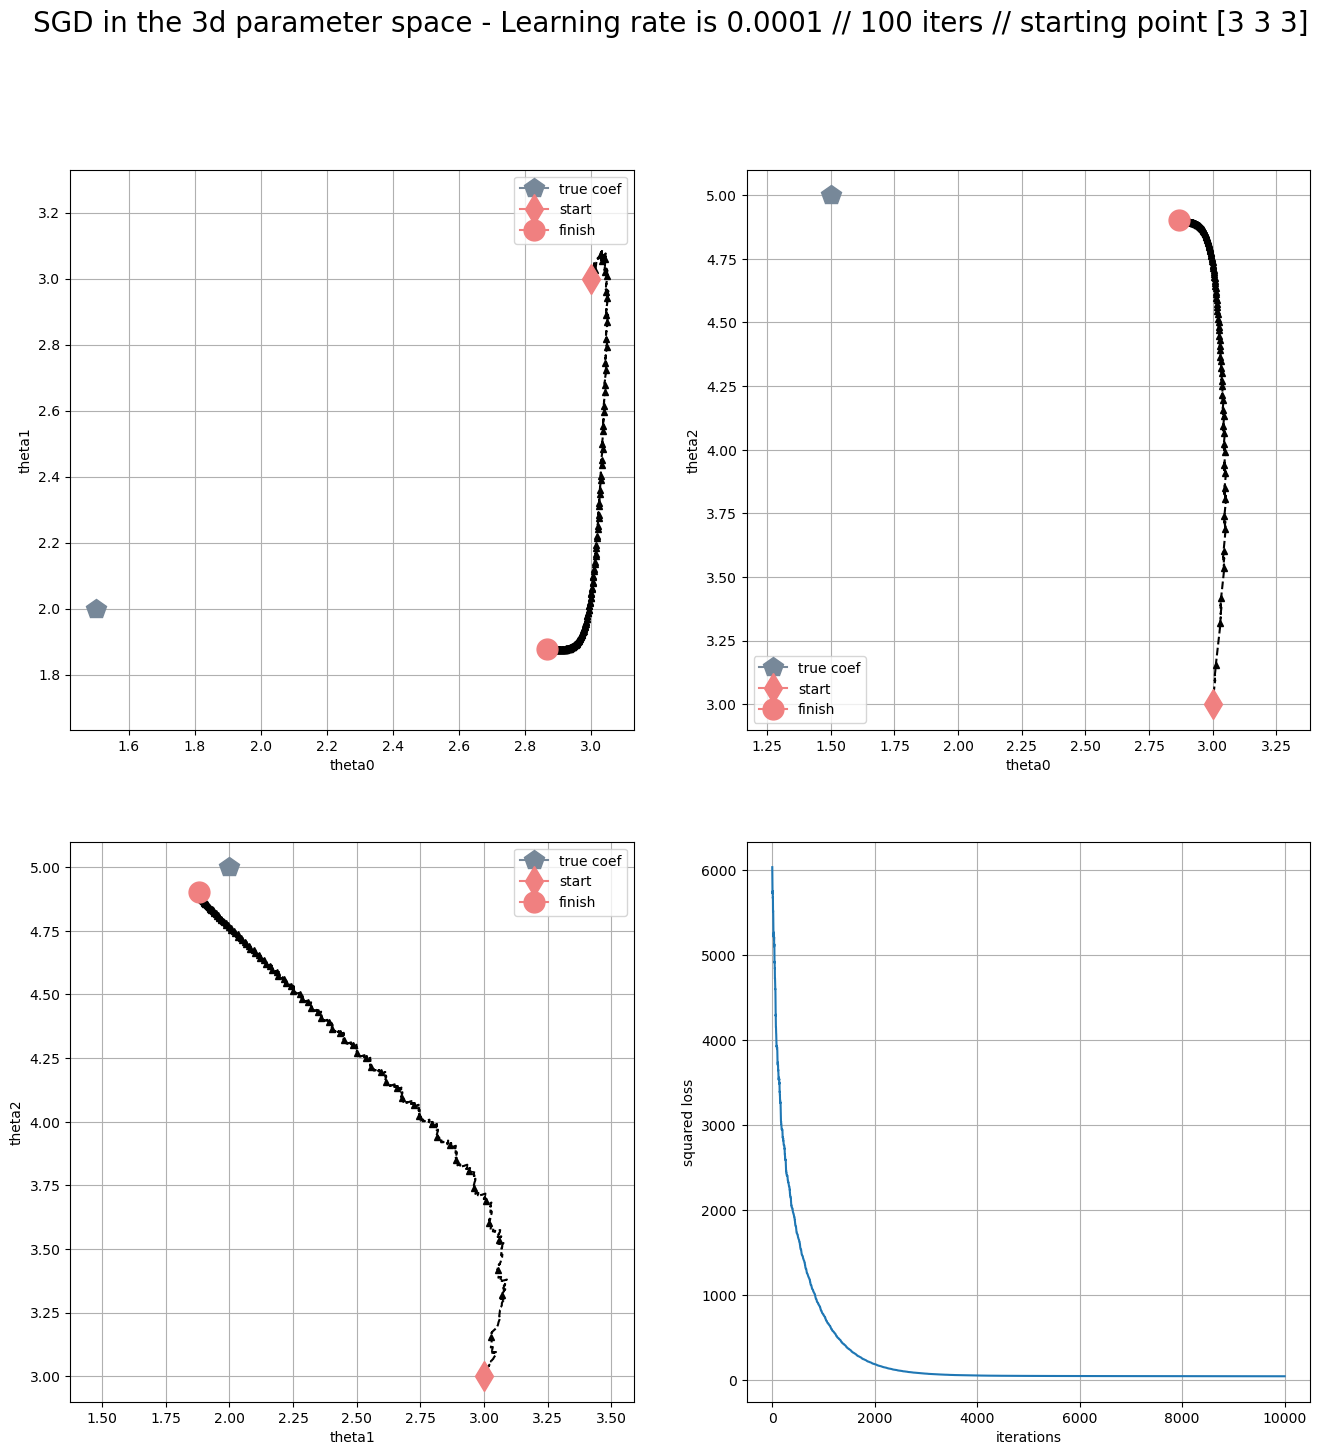

In [15]:
def stochastic_gradient_descent(learning_rate, num_iter, theta_initial):

    ## Initialization steps
    theta = theta_initial
    # below are different in STOCHASTIC gradient descent
    theta_path = np.zeros(((num_iter*num_obs)+1,3))
    theta_path[0,:] = theta_initial
    loss_vec = np.zeros(num_iter*num_obs)

    ## Main SGD loop
    count = 0
    for i in range(num_iter):
        for j in range(num_obs):
            count+=1
            y_pred = np.dot(theta.T,x_mat.T)
            loss_vec[count-1] = np.sum((y-y_pred)**2)
            grad_vec = (y[j]-y_pred[j])*(x_mat[j,:])
            theta = theta + learning_rate*grad_vec
            theta_path[count,:]=theta
    return theta_path, loss_vec

## Parameters to play with
learning_rate = 1e-4
num_iter = 100
theta_initial = np.array([3, 3, 3])


theta_path, loss_vec = stochastic_gradient_descent(learning_rate, 
                                                   num_iter, 
                                                   theta_initial)
plot_all(theta_path, loss_vec, learning_rate, 
         num_iter, theta_initial, 'SGD')
plt.show()

这段代码实现的是**随机梯度下降**（SGD），与批量梯度下降的区别在于：每次参数更新只用一个样本的梯度，而不是用全体样本的平均梯度。下面逐步说明：

```python
def stochastic_gradient_descent(learning_rate, num_iter, theta_initial):
    ## Initialization steps
    theta = theta_initial
    # SGD 要记录每一次“单样本”更新后的参数，所以路径长度是 num_iter*num_obs + 1
    theta_path = np.zeros(((num_iter * num_obs) + 1, 3))
    theta_path[0, :] = theta_initial
    # 每处理一个样本就计算一次损失，所以 loss_vec 也要预留 num_iter*num_obs 个位置
    loss_vec = np.zeros(num_iter * num_obs)
```
- `theta`：当前参数  
- `theta_path`：记录从初始到每次更新后参数的轨迹，行数 = 迭代次数 × 样本数 + 1  
- `loss_vec`：记录每次更新前的总平方损失

```python
    ## Main SGD loop
    count = 0
    for i in range(num_iter):         # 外层：遍历 epoch（循环 num_iter 次整个数据集）
        for j in range(num_obs):      # 内层：遍历每一个样本
            count += 1
            # ① 用当前 theta 对所有样本做预测，并计算总损失
            y_pred = np.dot(theta.T, x_mat.T)
            loss_vec[count-1] = np.sum((y - y_pred)**2)

            # ② 用第 j 个样本的残差和特征计算梯度（仅针对这一行）
            grad_vec = (y[j] - y_pred[j]) * x_mat[j, :]

            # ③ 更新参数：沿着单样本梯度方向前进一步
            theta = theta + learning_rate * grad_vec

            # ④ 记录更新后的参数
            theta_path[count, :] = theta
    return theta_path, loss_vec
```
1. **双重循环**：  
   - **外层** `i` 代表完整遍历一次数据集（一个 epoch），总共做 `num_iter` 个 epoch；  
   - **内层** `j` 代表每次取出一个样本单独计算梯度并更新参数。  
2. **损失记录**：每次更新前先算一次用全体样本的平方误差并存入 `loss_vec`，这样可以观察训练过程总体误差的变化。  
3. **梯度计算**：只用第 `j` 个样本的残差 \((y_j - \hat y_j)\) 与对应特征向量的乘积，作为参数更新的梯度。  
4. **累计计数** `count`：从 1 开始，到 `num_iter*num_obs`，用来索引 `theta_path` 和 `loss_vec`。

最后时，你用

```python
theta_path, loss_vec = stochastic_gradient_descent(
    learning_rate=1e-4,
    num_iter=100,
    theta_initial=np.array([3,3,3])
)
plot_all(theta_path, loss_vec, learning_rate, num_iter, theta_initial, 'SGD')
plt.show()
```

来可视化 **SGD** 在 100 个 epoch × 全样本数 次更新中的参数轨迹和损失下降情况。由于每次只用一个样本更新，SGD 的路径通常更“抖动”但收敛速度（总更新次数）会更快，更适合大规模数据场景。

Play with the parameters below and observe the trajectory it results in


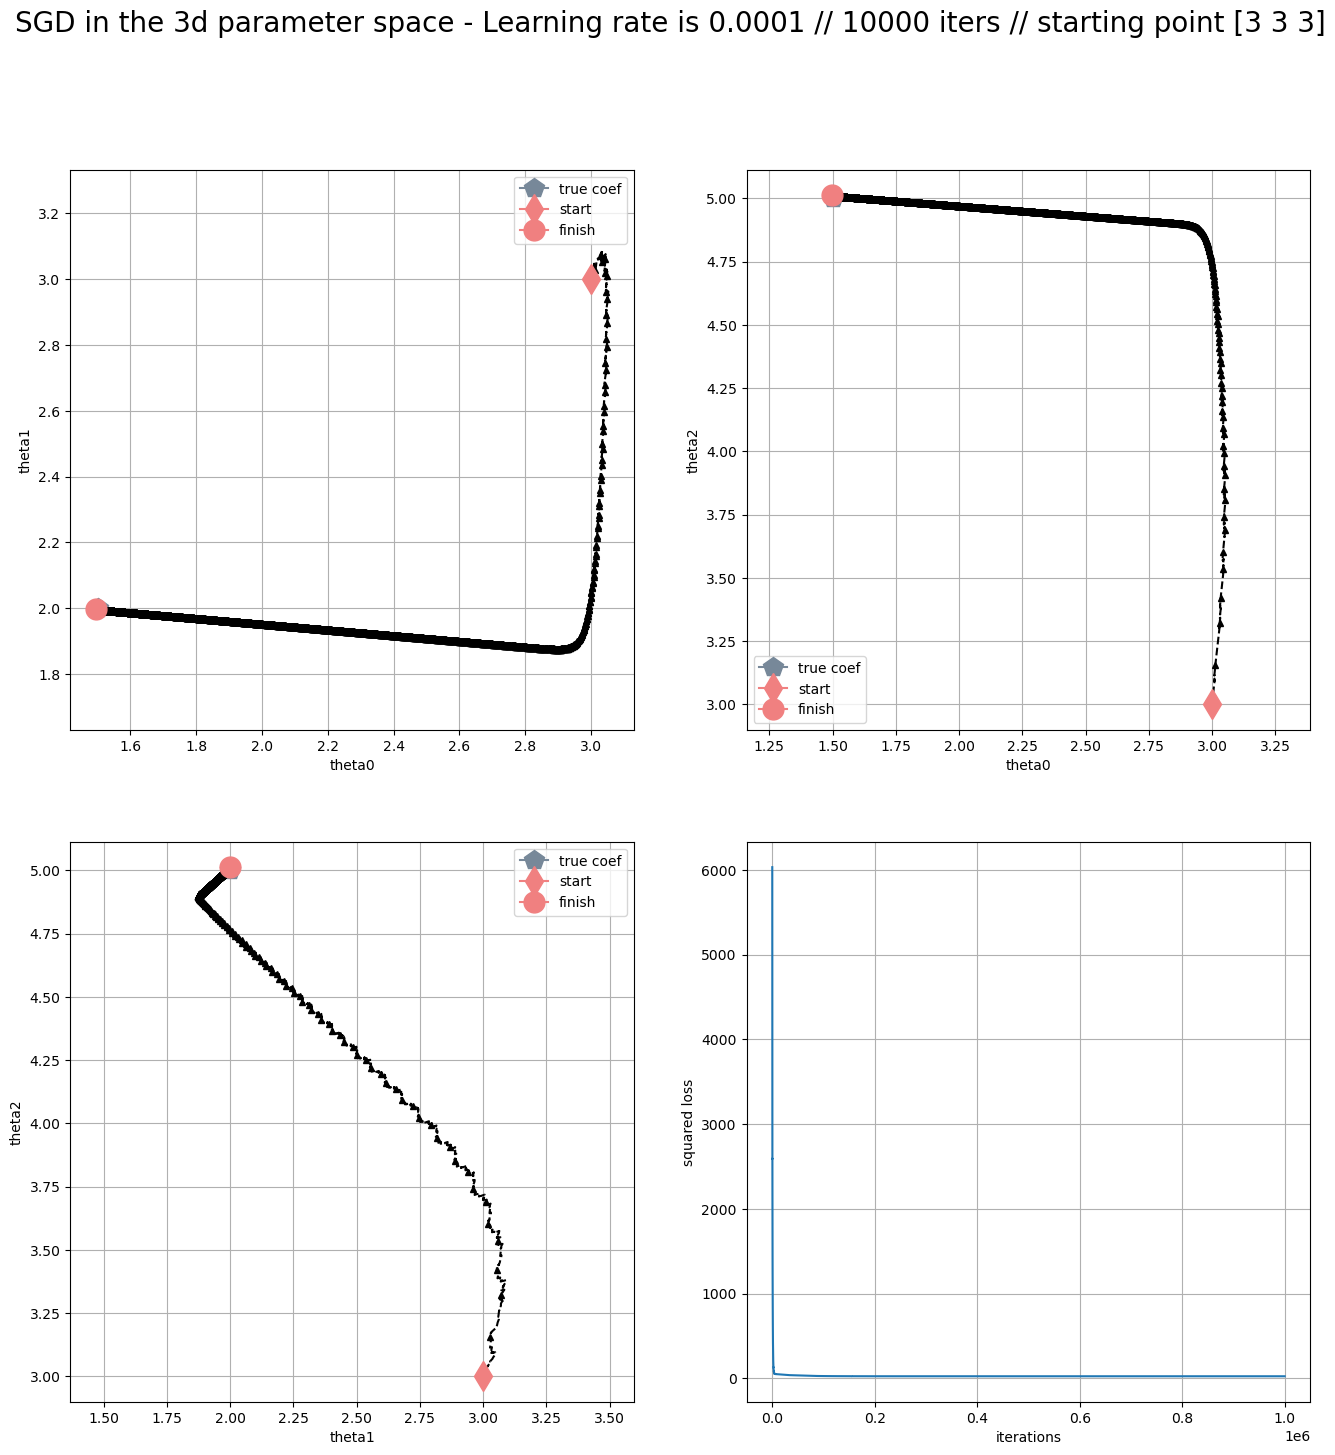

In [18]:
## Parameters to play with
learning_rate = 1e-4
num_iter = 10000
theta_initial = np.array([3,3,3])


theta_path, loss_vec = stochastic_gradient_descent(learning_rate, 
                                                   num_iter, 
                                                   theta_initial)
plot_all(theta_path, loss_vec, learning_rate, num_iter, 
         theta_initial, 'SGD')
plt.show()

---
### Machine Learning Foundation (C) 2020 IBM Corporation
